# Linear Regression Model

## Clean and Manage Dataset

In [154]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA = Path(r'C:\Users\minju\Desktop\CSProjects\whaleTracker\predictionModel\dwca-futurismo-data')

occ  = pd.read_csv(DATA / 'occurrence.txt',                sep='\t', low_memory=False)
evt  = pd.read_csv(DATA / 'event.txt',                     sep='\t', low_memory=False)
emof = pd.read_csv(DATA / 'extendedmeasurementorfact.txt', sep='\t', low_memory=False)


In [155]:
print(df.columns.tolist())

['eventID', 'scientificName', 'decimalLatitude', 'decimalLongitude', 'eventDate', 'beaufort', 'visibility_bin', 'event_start', 'month', 'visibility_km']


In [156]:
# keep_list = ['id', 'occurrenceID', 'organismQuantity', 'organismQuantityType', 'sex',
#              'lifeStage', 'associatedTaxa', 'eventID',
#              'verbatimIdentification', 'scientificNameID', 'scientificName',
#              'kingdom', 'phylum', 'class', 'order', 'family', 'genus']
# occ = occ.drop(columns=[col for col in occ.columns if col not in keep_list])

# keep_listevt = ['id', 'institutionCode', 'eventID', 'eventDate'
#                 , 'decimalLatitude', 'decimalLongitude',
#                 'coordinateUncertaintyInMeters', 'footprintWKT']
# evt = evt.drop(columns=[col for col in evt.columns if col not in keep_listevt]) 

# keep_list_emof = ['id', 'measurementID', 'occurrenceID', 'measurementType',
#                   'measurementValue', 'measurementUnit'
# ]
                  
# emof = emof.drop(columns=[col for col in emof.columns if col not in keep_list_emof]) 

# # print(evt['parentEventID'].value_counts())


# df = (occ.merge(evt,  on='eventID', how='outer', suffixes=('_occ', '_evt'))
#          .merge(emof, left_on='id_occ', right_on='id', how='outer', suffixes=('', '_emof')))

# print(df.shape)
# df.head()

In [157]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA = Path(r'C:\Users\minju\Desktop\CSProjects\whaleTracker\predictionModel\dwca-futurismo-data')

occ = pd.read_csv(DATA / 'occurrence.txt', sep='\t', low_memory=False)
evt = pd.read_csv(DATA / 'event.txt',      sep='\t', low_memory=False)
emof = pd.read_csv(DATA / 'extendedmeasurementorfact.txt', sep='\t', low_memory=False)

# Pivot emof long  wide
wanted = ['Beaufort wind force', 'visibility']
emof_wide = (emof[emof['measurementType'].isin(wanted)]
             .pivot_table(index='id', columns='measurementType',
                          values='measurementValue', aggfunc='first')
             .reset_index()
             .rename(columns={'id': 'eventID',
                              'Beaufort wind force': 'beaufort',
                              'visibility': 'visibility_bin'}))

df = (occ[['eventID', 'scientificName']]
      .merge(evt[['eventID', 'decimalLatitude', 'decimalLongitude', 'eventDate']], on='eventID', how='left')
      .merge(emof_wide, on='eventID', how='left'))
print(df.shape)
df.head()

(20413, 7)


,eventID,scientificName,decimalLatitude,decimalLongitude,eventDate,beaufort,visibility_bin
0,FUT_SM0818_cruise0001:encounter00001,Tursiops truncatus,37.690183,-25.486567,2008-05-03T10:00/2008-05-03T10:30,5,3
1,FUT_SM0818_cruise0001:encounter00002,Delphinus delphis,37.633433,-25.417500,2008-05-03T10:50/2008-05-03T11:10,5,5
2,FUT_SM0818_cruise0002:encounter00003,Delphinus delphis,37.716950,-25.633417,2008-05-03T13:20/2008-05-03T13:40,4,15
3,FUT_SM0818_cruise0002:encounter00004,Tursiops truncatus,37.668217,-25.573200,2008-05-03T14:00/2008-05-03T14:20,4,20
4,FUT_SM0818_cruise0003:encounter00005,Delphinus delphis,37.668217,-25.573200,2008-05-06/2008-05-06,1,25


# Feature Engineering

In [158]:
df['event_start'] = pd.to_datetime(df['eventDate'].str.split('/').str[0], errors='coerce')
df['month'] = df['event_start'].dt.month

vis_map = {
    '< 1':     0.5,
    '1  5':   3.0, '1 - 5':  3.0,
    '5  10':  7.5, '5 - 10': 7.5,
    '10  15': 12.5, '10 - 15': 12.5,
    '> 15':    20.0,
}
df['visibility_km'] = df['visibility_bin'].map(vis_map)
df['beaufort'] = pd.to_numeric(df['beaufort'], errors='coerce')

core = ['decimalLatitude', 'decimalLongitude', 'event_start', 'month',
        'beaufort', 'visibility_km', 'scientificName']
df_model = df.dropna(subset=core).copy()
print('rows kept:', len(df_model), '/', len(df))

rows kept: 13153 / 20413


# Fetch Weather data from Lat, Long

In [159]:
import requests

lat_c = float(df_model['decimalLatitude'].mean())
lon_c = float(df_model['decimalLongitude'].mean())
d_min = df_model['event_start'].dt.date.min().isoformat()
d_max = df_model['event_start'].dt.date.max().isoformat()
print(f'fetching ({lat_c:.3f}, {lon_c:.3f}) from {d_min} to {d_max}')

weather_vars = ['temperature_2m', 'surface_pressure', 'pressure_msl',
                'dew_point_2m', 'wind_speed_10m', 'relative_humidity_2m']

resp = requests.get(
    'https://archive-api.open-meteo.com/v1/archive',
    params={
        'latitude': lat_c, 'longitude': lon_c,
        'start_date': d_min, 'end_date': d_max,
        'hourly': ','.join(weather_vars),
    },
    timeout=120,
)
resp.raise_for_status()
data = resp.json()['hourly']

weather = pd.DataFrame(data)
weather['time'] = pd.to_datetime(weather['time'])

df_model['event_hour'] = df_model['event_start'].dt.floor('h')
df_model = df_model.merge(weather, left_on='event_hour', right_on='time', how='left')
df_model = df_model.dropna(subset=weather_vars).copy()
print('rows after weather merge:', len(df_model))
weather_cols = weather_vars


fetching (37.659, -25.606) from 2009-09-18 to 2018-12-27
rows after weather merge: 13153


In [160]:
df_model.head()

,eventID,scientificName,decimalLatitude,decimalLongitude,eventDate,beaufort,visibility_bin,event_start,month,visibility_km,event_hour,time,temperature_2m,surface_pressure,pressure_msl,dew_point_2m,wind_speed_10m,relative_humidity_2m
0,FUT_SM0818_cruise0616:encounter01979,Stenella frontalis,37.650960,-25.67142,2009-09-18T09:37/2009-09-18T09:56,0.0,> 15,2009-09-18 09:37:00,9,20.0,2009-09-18 09:00:00,2009-09-18 09:00:00,18.9,1021.4,1021.4,14.0,6.4,73
1,FUT_SM0818_cruise0616:encounter01980,Delphinus delphis,37.641650,-25.69129,2009-09-18T09:59/2009-09-18T10:11,0.0,> 15,2009-09-18 09:59:00,9,20.0,2009-09-18 09:00:00,2009-09-18 09:00:00,18.9,1021.4,1021.4,14.0,6.4,73
2,FUT_SM0818_cruise0616:encounter01981,Tursiops truncatus,37.629335,-25.63208,2009-09-18T10:25/2009-09-18T10:47,1.0,> 15,2009-09-18 10:25:00,9,20.0,2009-09-18 10:00:00,2009-09-18 10:00:00,20.0,1021.1,1021.1,13.9,6.6,68
3,FUT_SM0818_cruise0616:encounter01982,Delphinus delphis,37.659785,-25.54508,2009-09-18T11:05/2009-09-18T11:20,0.0,> 15,2009-09-18 11:05:00,9,20.0,2009-09-18 11:00:00,2009-09-18 11:00:00,20.5,1021.9,1021.9,13.8,10.1,66
4,FUT_SM0818_cruise0617:encounter01983,Balaenoptera physalus,37.910110,-25.05316,2009-09-18T14:40/2009-09-18T15:10,2.0,> 15,2009-09-18 14:40:00,9,20.0,2009-09-18 14:00:00,2009-09-18 14:00:00,21.2,1021.4,1021.4,14.1,14.8,64


Text(0.5, 1.0, 'location and species')

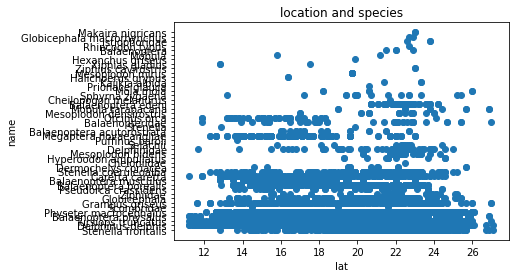

In [161]:
#choose an x feature to predict a y feature, data exploration/visualization
#dfBelgium.dtypes

plt.scatter(df_model['temperature_2m'], df_model['scientificName'])
plt.xlabel('lat')
plt.ylabel('name')
plt.title('location and species')


# Model

In [162]:
def add_bias_column(X):
    """
    Args:
        X (array): can be either 1-d or 2-d
    
    Returns:
        Xnew (array): the same array, but 2-d with a column of 1's in the first spot
    """
    
    # If the array is 1-d
    if len(X.shape) == 1:
        Xnew = np.column_stack([np.ones(X.shape[0]), X])
    
    # If the array is 2-d
    elif len(X.shape) == 2:
        bias_col = np.ones((X.shape[0], 1))
        Xnew = np.hstack([bias_col, X])
        
    else:
        raise ValueError("Input array must be either 1-d or 2-d")

    return Xnew

In [163]:
def line_of_best_fit(X,y):
    """
    Args:
        X (array): can be either 1-d or 2-d
        y (array): 1-d array
    
    Returns:
        vect (array): coefficients for line of best fit, with intercept
    """
    colAdded = add_bias_column(X)
    b, *_ = np.linalg.lstsq(colAdded, y, rcond=None) 
    return b



In [164]:
def linreg_predict(Xnew, ynew, b):
    """
    Args:
        Xnew (array): can be either 1-d or 2-d
        ynew (array): array with corresponding vals to Xnew (1-d or 2-d for multi-output)
        b (array): coefficients from line of best fit (length p+1, or (p+1, k) for multi-output)

    Returns:
        modelDict (dict): contains {ypreds: predicted vals, resids: difference between ynew and preds, mse: mean squared error, r2: coefficient of determination}
    """
    # convert pandas inputs to numpy so subtraction is positional, not label-aligned
    ynew = np.asarray(ynew, dtype=float)
    b = np.asarray(b, dtype=float)

    y_pred = add_bias_column(np.asarray(Xnew, dtype=float)) @ b
    res = y_pred - ynew
    mse = float(np.mean(res ** 2))           # scalar over all outputs
    r2 = r2_score(ynew, y_pred)              # averaged over outputs for multi-output

    modelDict = {'ypreds': y_pred, 'resids': res, 'mse': mse, 'r2': r2}
    return modelDict



# Train Model

In [175]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

feature_cols = ['month', 'beaufort', 'visibility_km',
                'temperature_2m', 'surface_pressure', 'pressure_msl',
                'dew_point_2m', 'wind_speed_10m', 'relative_humidity_2m']
X = pd.concat([
    df_model[feature_cols].reset_index(drop=True),
    pd.get_dummies(df_model['scientificName'], prefix='sp').reset_index(drop=True),
], axis=1)
y = df_model[['decimalLatitude', 'decimalLongitude']].reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 1. drop constant columns (no information; break the inverse)
const_cols = [c for c in X_train.columns if X_train[c].nunique() <= 1]
X_train = X_train.drop(columns=const_cols)
X_test  = X_test.drop(columns=const_cols)   # keep test aligned

# 2. drop the duplicate pressure column
if {'surface_pressure', 'pressure_msl'} <= set(X_train.columns):
    X_train = X_train.drop(columns=['pressure_msl'])
    X_test  = X_test.drop(columns=['pressure_msl'])


print("shape:", X_train.shape)
print("constant cols:", [c for c in X_train.columns if X_train[c].nunique() <= 1])
print("rank:", np.linalg.matrix_rank(X_train.values), "vs n_features:", X_train.shape[1])
print(X_train.corr())   # look for any pair == 1.0


# apply the `line_of_best_fit` function to training data and use the
# `linreg_predict`function with the test data

b=line_of_best_fit(X_train, y_train)
results = linreg_predict(X_test, y_test, b)

shape: (10522, 51)
constant cols: []
rank: 51 vs n_features: 51
                                  month  beaufort  temperature_2m  \
month                          1.000000 -0.054554        0.501017   
beaufort                      -0.054554  1.000000       -0.118936   
temperature_2m                 0.501017 -0.118936        1.000000   
surface_pressure              -0.145090 -0.182985       -0.132204   
dew_point_2m                   0.415037 -0.141075        0.852740   
wind_speed_10m                -0.062191  0.555388       -0.049713   
relative_humidity_2m           0.026730 -0.088621        0.092297   
sp_Balaenoptera                0.015624  0.021586        0.012480   
sp_Balaenoptera acutorostrata -0.025004 -0.028748       -0.014211   
sp_Balaenoptera borealis      -0.062703  0.040042       -0.041925   
sp_Balaenoptera edeni          0.044691 -0.014511        0.068668   
sp_Balaenoptera musculus      -0.142703  0.064542       -0.139395   
sp_Balaenoptera physalus      -0.232636

In [ ]:
# from sklearn.model_selection import train_test_split
# from sklearn.metrics import mean_absolute_error, r2_score

# #feats
# cont_cols = ['beaufort', 'visibility_km',
#              'temperature_2m', 'surface_pressure',
#              'dew_point_2m', 'wind_speed_10m', 'relative_humidity_2m']
# # (dropped pressure_msl: it duplicates surface_pressure)

# base = df_model.copy()

# # make month a cycle to account for time
# base['month_sin'] = np.sin(2 * np.pi * base['month'] / 12)
# base['month_cos'] = np.cos(2 * np.pi * base['month'] / 12)

# species = pd.get_dummies(base['scientificName'], prefix='sp').astype(float)

# # species x season interactions: lets each species shift location seasonally
# inter = pd.concat(
#     [species.mul(base['month_sin'].values, axis=0).add_suffix('_msin'),
#      species.mul(base['month_cos'].values, axis=0).add_suffix('_mcos')],
#     axis=1)

# X = pd.concat([
#     base[cont_cols + ['month_sin', 'month_cos']].reset_index(drop=True),
#     species.reset_index(drop=True),
#     inter.reset_index(drop=True),
# ], axis=1).astype(float)
# y = base[['decimalLatitude', 'decimalLongitude']].reset_index(drop=True)

# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42)

# #standardize continuous cols
# mu = X_train[cont_cols].mean()
# sd = X_train[cont_cols].std().replace(0, 1)
# X_train.loc[:, cont_cols] = (X_train[cont_cols] - mu) / sd
# X_test.loc[:,  cont_cols] = (X_test[cont_cols]  - mu) / sd

# # drop constant cols
# const_cols = [c for c in X_train.columns if X_train[c].nunique() <= 1]
# X_train = X_train.drop(columns=const_cols)
# X_test  = X_test.drop(columns=const_cols)

# print("shape:", X_train.shape)
# print("rank:", np.linalg.matrix_rank(X_train.values), "vs n_features:", X_train.shape[1])

# #pred
# b = line_of_best_fit(X_train, y_train)
# results = linreg_predict(X_test, y_test, b)
# print("MSE:", results['mse'])
# print("R2 :", results['r2'])


c:\Users\minju\anaconda3\lib\site-packages\pandas\core\indexing.py:1637: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self._setitem_single_block(indexer, value, name)
c:\Users\minju\anaconda3\lib\site-packages\pandas\core\indexing.py:692: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value, self.name)


shape: (10522, 140)
rank: 110 vs n_features: 140
MSE: 0.017363796018519586
R2 : 0.03889352962491388


# Plots for residuls, MSE

MSE: 0.017363796018519586
R2 : 0.03889352962491388


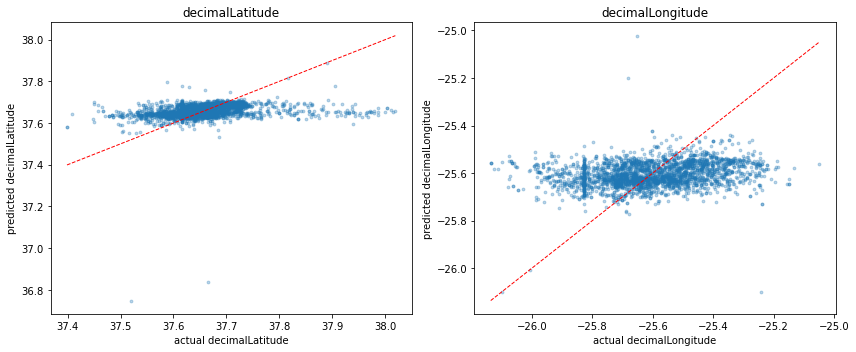

In [174]:
import matplotlib.pyplot as plt

print("MSE:", results['mse'])
print("R2 :", results['r2'])

y_pred = results['ypreds']
y_true = y_test.to_numpy()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for i, name in enumerate(['decimalLatitude', 'decimalLongitude']):
    ax[i].scatter(y_true[:, i], y_pred[:, i], s=8, alpha=0.3)
    lo, hi = y_true[:, i].min(), y_true[:, i].max()
    ax[i].plot([lo, hi], [lo, hi], 'r--', lw=1)   # perfect-prediction line
    ax[i].set_xlabel(f'actual {name}')
    ax[i].set_ylabel(f'predicted {name}')
    ax[i].set_title(name)
plt.tight_layout()
plt.show()


# Assumptions Check
### Check the assumptions of linearity, homoscedasticity, and no autocorrelation using the residuals of the full data set.
